# 02 — Корректная оценка LoRA-адаптера на `GQA-ru` и `MMBench-ru`

Этот ноутбук **не обучает модель**. Он загружает базовую `deepvk/llava-gemma-2b-lora`
и готовый LoRA-адаптер из Google Drive, после чего измеряет качество обеих моделей
на бенчмарках с доверительными интервалами и проверкой статистической значимости.

## Чем отличается от оценки в `01_train_lora.ipynb`

В первом ноутбуке оценка выполнялась сразу после `trainer.train()`, когда модель
оставалась в режиме `train()` с активным gradient checkpointing. Из-за этого:

1. KV-кэш отключался на каждом слое декодера;
2. `LlavaForConditionalGeneration` передаёт `pixel_values` в forward только при
   `cache_position[0] == 0`, то есть на первом шаге генерации;
3. начиная со второго токена изображение исчезало из контекста — 576 плейсхолдеров
   `<image>` получали обычные текстовые эмбеддинги.

Валиден был только первый сгенерированный токен. MMBench (одна буква) это пережил,
GQA (целое русское слово) — нет, отсюда Exact Match = 0.000 у базовой модели при
опубликованных авторами 46.37.

Здесь модель переводится в `eval()`, gradient checkpointing выключается, KV-кэш
включается, а корректность проверяется явными ассертами перед долгим прогоном.

## Что нужно для запуска

- Runtime → Change runtime type → **T4 GPU**
- Архив с адаптером на Google Drive (по умолчанию
  `/content/drive/MyDrive/llava-gemma-gqa-ru/submission_bundle.zip`)

## Порядок работы

Runtime → Run all. Ноутбук сам смонтирует Drive, найдёт адаптер, прогонит быструю
проверку на 20 примерах и только потом запустит полную оценку. Если быстрая проверка
покажет Exact Match = 0, ноутбук остановится с диагностикой — не тратя часы впустую.

## 0. Установка зависимостей

Версии закреплены намеренно, как и в `01_train_lora.ipynb`:

- `pillow<12` — в Pillow 12.0+ `PIL/ImageDraw.py` импортирует `PIL.ImageText`, который
  тянет несуществующее имя `_Ink` из `PIL._typing`; падает прямо на `import peft`
- `transformers<5` — в v5 регресс bitsandbytes 4-bit + `device_map="auto"`:
  часть параметров материализуется мимо квантизатора, `lm_head` теряет `quant_state`

In [1]:
!pip install -q -U "transformers>=4.46,<5" "accelerate>=0.31" "peft>=0.11" "bitsandbytes>=0.43" \
    "datasets>=2.19" sentencepiece matplotlib tqdm scipy
!pip install -q --force-reinstall --no-deps "pillow<12,>=10.0.0"

import os

def _pil_chain_ok():
    try:
        import PIL.ImageDraw
        return True
    except Exception:
        return False

if not _pil_chain_ok():
    print("В памяти ядра осталась несовместимая версия Pillow — перезапускаю среду.")
    print("После перезапуска выполните Runtime -> Run all ещё раз.")
    os.kill(os.getpid(), 9)
else:
    print("Зависимости в порядке.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 6.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 77.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 53.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 676.7/676.7 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 11.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not 

In [2]:
import transformers, peft, torch, datasets, accelerate

print("transformers:", transformers.__version__)
print("peft:        ", peft.__version__)
print("torch:       ", torch.__version__)
print("datasets:    ", datasets.__version__)
print("accelerate:  ", accelerate.__version__)
print()
print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0),
          f"| {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
else:
    print("ВНИМАНИЕ: GPU не найден. Runtime -> Change runtime type -> T4 GPU")

transformers: 4.57.6
peft:         0.19.1
torch:        2.11.0+cu128
datasets:     5.0.0
accelerate:   1.14.0

CUDA: True
GPU: Tesla T4 | 14.6 GB


## 1. Конфигурация

Все настройки собраны в одной ячейке.

**Про `ADD_SPECIAL_TOKENS`.** Chat template этого чекпоинта, в отличие от стандартного
шаблона Gemma, токен `<bos>` не вставляет. Поэтому флаг решает не «один BOS или два»,
а «есть BOS или нет вовсе»:

- `False` — промпт без `<bos>`. Именно в этом режиме обучался адаптер
  в `01_train_lora.ipynb`.
- `True` — токенизатор добавляет `<bos>` в начало. Штатный режим Gemma; соответствует
  примеру использования из карточки модели deepvk.

Gemma обучалась так, что каждая последовательность начиналась с `<bos>`, и базовая модель
к его отсутствию чувствительна. Адаптер, обученный без него, — нет. Поэтому режим промпта
вынесен в отдельный измеряемый фактор: раздел 17 прогоняет все четыре комбинации
`модель × режим` и показывает, какая часть наблюдаемой разницы между моделями объясняется
дообучением, а какая — форматом входа.

По умолчанию стоит `False`, чтобы промпт на оценке совпадал с промптом на обучении.
Фактическую токенизацию для обоих значений печатает раздел 4.

In [ ]:
import random
import numpy as np

# модель и данные 
MODEL_NAME = "deepvk/llava-gemma-2b-lora"
GQA_DATASET = "deepvk/GQA-ru"
MMBENCH_DATASET = "deepvk/MMBench-ru"

# адаптер 
# Ноутбук по очереди проверяет: локальную папку -> архив на Drive -> папку на Drive.
DRIVE_DIR = "/content/drive/MyDrive/llava-gemma-gqa-ru"
ADAPTER_ZIP = f"{DRIVE_DIR}/submission_bundle.zip"
ADAPTER_DIR_LOCAL = "/content/llava-gemma-2b-lora-gqa-ru-adapter"

# параметры оценки 
SEED = 42
EVAL_N_GQA = 1000        # из 12 216 в testdev
EVAL_N_MMBENCH = 1000    # из 3 910 в dev
BATCH_SIZE = 8           
N_BOOTSTRAP = 10000

POST_PROMPT_GQA = "Ответь одним словом."
MMBENCH_INSTRUCTION = "Выбери один правильный вариант ответа и напиши только его букву (A, B, C или D)."
GQA_MAX_NEW_TOKENS = 10
MMBENCH_MAX_NEW_TOKENS = 5
STRIP_CHARS = ".,!?;:\"'()[]«»"

ADD_SPECIAL_TOKENS = False   

# куда складывать результаты
RESULTS_DIR = "/content/results"
os.makedirs(RESULTS_DIR, exist_ok=True)


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(SEED)
print("Конфигурация загружена. Оценка:",
      f"GQA {EVAL_N_GQA} + MMBench {EVAL_N_MMBENCH} примеров, батч {BATCH_SIZE}.")

Конфигурация загружена. Оценка: GQA 1000 + MMBench 1000 примеров, батч 8.


## 2. Google Drive и поиск адаптера

Ячейка ниже монтирует Drive, при необходимости распаковывает архив и ищет папку,
в которой лежит `adapter_config.json`. Если адаптер уже распакован локально —
Drive не понадобится.

In [4]:
import glob
import shutil
import zipfile


def find_adapter_dir(root):
    # Ищет папку с adapter_config.json внутри root, включая вложенные.
    if not os.path.isdir(root):
        return None
    if os.path.exists(os.path.join(root, "adapter_config.json")):
        return root
    hits = glob.glob(os.path.join(root, "**", "adapter_config.json"), recursive=True)
    return os.path.dirname(hits[0]) if hits else None


ADAPTER_DIR = find_adapter_dir(ADAPTER_DIR_LOCAL)

if ADAPTER_DIR is None:
    from google.colab import drive
    drive.mount("/content/drive")

    if os.path.exists(ADAPTER_ZIP):
        print(f"Распаковываю {ADAPTER_ZIP} ...")
        with zipfile.ZipFile(ADAPTER_ZIP) as zf:
            zf.extractall("/content/adapter_unpacked")
        ADAPTER_DIR = find_adapter_dir("/content/adapter_unpacked")
    else:
        ADAPTER_DIR = find_adapter_dir(DRIVE_DIR)

if ADAPTER_DIR is None:
    raise FileNotFoundError(
        "Не нашёл adapter_config.json.\n"
        f"Проверял: {ADAPTER_DIR_LOCAL}, {ADAPTER_ZIP}, {DRIVE_DIR}\n"
        "Укажите правильный путь в разделе 1 (DRIVE_DIR / ADAPTER_ZIP)."
    )

print("Адаптер найден:", ADAPTER_DIR)
for f in sorted(os.listdir(ADAPTER_DIR)):
    size = os.path.getsize(os.path.join(ADAPTER_DIR, f)) / 1e6
    print(f"  {f:40s} {size:8.2f} МБ")

Mounted at /content/drive
Распаковываю /content/drive/MyDrive/llava-gemma-gqa-ru/submission_bundle.zip ...
Адаптер найден: /content/adapter_unpacked/llava-gemma-2b-lora-gqa-ru-adapter
  README.md                                    0.01 МБ
  adapter_config.json                          0.00 МБ
  adapter_model.safetensors                   78.48 МБ
  added_tokens.json                            0.00 МБ
  chat_template.jinja                          0.00 МБ
  preprocessor_config.json                     0.00 МБ
  processor_config.json                        0.00 МБ
  special_tokens_map.json                      0.00 МБ
  tokenizer.json                              34.36 МБ
  tokenizer.model                              4.24 МБ
  tokenizer_config.json                        0.04 МБ


In [5]:
import json

with open(os.path.join(ADAPTER_DIR, "adapter_config.json")) as f:
    adapter_cfg = json.load(f)

print("Базовая модель адаптера:", adapter_cfg.get("base_model_name_or_path"))
print("r =", adapter_cfg.get("r"), "| alpha =", adapter_cfg.get("lora_alpha"),
      "| dropout =", adapter_cfg.get("lora_dropout"))
print("target_modules:", adapter_cfg.get("target_modules"))

if adapter_cfg.get("base_model_name_or_path") not in (None, MODEL_NAME):
    print("\nВНИМАНИЕ: адаптер обучался поверх другой базовой модели —",
          "проверьте MODEL_NAME в разделе 1.")

Базовая модель адаптера: deepvk/llava-gemma-2b-lora
r = 16 | alpha = 32 | dropout = 0.05
target_modules: .*language_model.*\.(q_proj|k_proj|v_proj|o_proj|gate_proj|up_proj|down_proj)$


## 3. Загрузка базовой модели и адаптера

Базовая модель загружается **точно так же, как при обучении** — 4-bit NF4, с теми же
исключениями из квантования. Это обязательно: имена модулей должны совпасть с теми,
на которые навешивался LoRA.

In [ ]:
from transformers import (
    AutoProcessor,
    AutoTokenizer,
    LlavaForConditionalGeneration,
    BitsAndBytesConfig,
)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    llm_int8_skip_modules=["vision_tower", "multi_modal_projector", "lm_head"],
)

processor = AutoProcessor.from_pretrained(MODEL_NAME)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

base_model = LlavaForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    dtype=torch.float16,
)

if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token

# processor_config.json чекпоинта сохранён до появления этих полей, без них
# LlavaProcessor не знает, во сколько токенов разворачивать <image>, и падает на `//`.
processor.patch_size = base_model.config.vision_config.patch_size
processor.vision_feature_select_strategy = base_model.config.vision_feature_select_strategy
processor.num_additional_image_tokens = 1 if processor.vision_feature_select_strategy == "default" else 0
processor.tokenizer.pad_token = tokenizer.pad_token

print("Базовая модель загружена.")
print("patch_size:", processor.patch_size,
      "| strategy:", processor.vision_feature_select_strategy,
      "| extra tokens:", processor.num_additional_image_tokens)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/67.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/505 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


tokenizer_config.json: 0.00B [00:00, ?B/s]

...

model-00003-of-00003.safetensors:   0%|          | 0.00/1.30G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/139 [00:00<?, ?B/s]

Базовая модель загружена.
patch_size: 14 | strategy: default | extra tokens: 1


In [7]:
from peft import PeftModel

model = PeftModel.from_pretrained(base_model, ADAPTER_DIR, is_trainable=False)

n_lora = sum(p.numel() for n, p in model.named_parameters() if "lora_" in n)
print(f"Адаптер подключён. Параметров LoRA: {n_lora:,}")

if n_lora == 0:
    raise RuntimeError(
        "LoRA-параметры не найдены — адаптер не прикрепился. "
        "Скорее всего, не совпали имена модулей: проверьте, что базовая модель "
        "загружена с тем же llm_int8_skip_modules, что и при обучении."
    )

Адаптер подключён. Параметров LoRA: 19,611,648


### 3.1 Приведение модели в корректный режим инференса

Ровно то, чего не хватало в первом ноутбуке. Ассерты ниже проверяют это явно,
чтобы ошибка не всплыла через два часа в виде нулевой метрики.

In [ ]:
model.eval()
model.config.use_cache = True

try:
    model.gradient_checkpointing_disable()
except Exception as e:
    print("gradient_checkpointing_disable():", e)

# проверки
assert not model.training, "Модель в режиме train() — генерация будет некорректной."

gc_on = [n for n, m in model.named_modules() if getattr(m, "gradient_checkpointing", False)]
assert not gc_on, f"Gradient checkpointing активен у {len(gc_on)} модулей: {gc_on[:3]} ..."

assert model.config.use_cache, "use_cache выключен — KV-кэш не будет работать."

# dtype визуальной части: prepare_model_for_kbit_training мог поднять её до fp32, поэтому определяем фактический тип, а не хардкодим float16.
VISION_DTYPE = torch.float16
for n, p in model.named_parameters():
    if "vision_tower" in n:
        VISION_DTYPE = p.dtype
        break

print("Модель в eval(), gradient checkpointing выключен, KV-кэш включён.")
print("dtype визуальной части:", VISION_DTYPE)

Модель в eval(), gradient checkpointing выключен, KV-кэш включён.
dtype визуальной части: torch.float16


## 4. Диагностика промпта

Смотрим, как реально токенизируется промпт при обоих значениях `ADD_SPECIAL_TOKENS`,
и сколько токенов занимает картинка. Дублирование `<bos>` видно невооружённым глазом.

In [9]:
def build_chat_prompt(user_text: str) -> str:
    messages = [{"role": "user", "content": f"<image>\n{user_text}"}]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)


_demo = build_chat_prompt("Какого цвета машина? " + POST_PROMPT_GQA)
print("Строка промпта (первые 120 символов):")
print(repr(_demo[:120]))
print()

for flag in (False, True):
    ids = tokenizer(_demo, add_special_tokens=flag).input_ids
    head = tokenizer.convert_ids_to_tokens(ids[:5])
    n_bos = sum(1 for t in head if "bos" in t.lower())
    print(f"add_special_tokens={flag!s:5s} -> первые токены: {head}  | <bos> в начале: {n_bos}")

print()
print("Используется ADD_SPECIAL_TOKENS =", ADD_SPECIAL_TOKENS)

Строка промпта (первые 120 символов):
'<start_of_turn>user\n<image>\nКакого цвета машина? Ответь одним словом.<end_of_turn>\n<start_of_turn>model\n'

add_special_tokens=False -> первые токены: ['<start_of_turn>', 'user', '\n', '<image>', '\n']  | <bos> в начале: 0
add_special_tokens=True  -> первые токены: ['<bos>', '<start_of_turn>', 'user', '\n', '<image>']  | <bos> в начале: 1

Используется ADD_SPECIAL_TOKENS = False


## 5. Батчевая генерация

Генерация батчами с **левым паддингом** — при правом паддинге модель продолжала бы
последовательность после `<pad>`, и ответы были бы мусорными. Левый паддинг даёт
всем примерам в батче одинаковую длину промпта, поэтому срез `[prompt_len:]`
корректен для всего батча сразу.

Ускорение относительно поштучной генерации — примерно в 3–4 раза.

In [10]:
@torch.no_grad()
def generate_answers(gen_model, images, user_texts, max_new_tokens=10):
    images = [im.convert("RGB") if im.mode != "RGB" else im for im in images]
    texts = [build_chat_prompt(t) for t in user_texts]

    processor.tokenizer.padding_side = "left"
    inputs = processor(
        images=images,
        text=texts,
        return_tensors="pt",
        padding=True,
        add_special_tokens=ADD_SPECIAL_TOKENS,
    )
    inputs = {k: v.to(gen_model.device) for k, v in inputs.items()}
    if "pixel_values" in inputs:
        inputs["pixel_values"] = inputs["pixel_values"].to(VISION_DTYPE)

    out = gen_model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        pad_token_id=tokenizer.pad_token_id,
    )

    prompt_len = inputs["input_ids"].shape[1]
    return [
        tokenizer.decode(seq[prompt_len:], skip_special_tokens=True).strip()
        for seq in out
    ]


def chunks(seq, size):
    for i in range(0, len(seq), size):
        yield seq[i:i + size]


print("Функции генерации готовы.")

Функции генерации готовы.


## 6. Sanity check — до долгого прогона

Две быстрые проверки. Первая — та же картинка со стоп-знаком, что в карточке модели:
ответ должен быть связным русским текстом, а не обрывком с мусором. Вторая — Exact Match
на 20 примерах GQA: если он окажется нулевым, ноутбук остановится.

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


База:  Опиши картинку несколько словами.
LoRA:  На фотографии изображен красный стоп-знак, который находится на углу улицы.


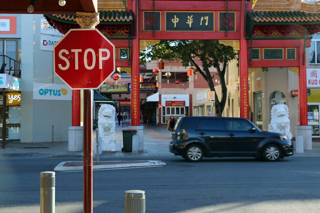

In [11]:
import requests
from PIL import Image
from IPython.display import display

test_image = Image.open(
    requests.get("https://www.ilankelman.org/stopsigns/australia.jpg", stream=True).raw
).convert("RGB")

ans_tuned = generate_answers(model, [test_image], ["Опиши картинку несколькими словами."], 30)[0]
with model.disable_adapter():
    ans_base = generate_answers(model, [test_image], ["Опиши картинку несколькими словами."], 30)[0]

print("База: ", ans_base)
print("LoRA: ", ans_tuned)
display(test_image.resize((320, 213)))

## 7. Загрузка данных

Обучающий сплит `GQA-ru` (3.89 ГБ картинок) **не загружается** — для оценки он не нужен.
Скачиваются только testdev (65 МБ) и MMBench (93 МБ).

In [12]:
from datasets import load_dataset, get_dataset_split_names


def load_split_safely(dataset_name, config_name, preferred_split):
    available = get_dataset_split_names(dataset_name, config_name)
    split = preferred_split if preferred_split in available else available[0]
    if split != preferred_split:
        print(f"[{config_name}] сплит '{preferred_split}' не найден, доступны {available} -> беру '{split}'")
    return load_dataset(dataset_name, config_name, split=split)


gqa_instructions = load_split_safely(GQA_DATASET, "testdev_balanced_instructions", "testdev")
gqa_images = load_split_safely(GQA_DATASET, "testdev_balanced_images", "testdev")
gqa_id_to_idx = {img_id: i for i, img_id in enumerate(gqa_images["id"])}

mmbench_ds = load_split_safely(MMBENCH_DATASET, "default", "dev")

print("GQA-ru testdev:", len(gqa_instructions), "вопросов,", len(gqa_images), "изображений")
print("MMBench-ru dev:", len(mmbench_ds), "вопросов")

README.md: 0.00B [00:00, ?B/s]

testdev_balanced_instructions/testdev-00(…):   0%|          | 0.00/1.95M [00:00<?, ?B/s]

Generating testdev split:   0%|          | 0/12216 [00:00<?, ? examples/s]

testdev_balanced_images/testdev-00000-of(…):   0%|          | 0.00/65.6M [00:00<?, ?B/s]

Generating testdev split:   0%|          | 0/398 [00:00<?, ? examples/s]

README.md: 0.00B [00:00, ?B/s]

mmbench_ru_dev.parquet:   0%|          | 0.00/92.7M [00:00<?, ?B/s]

Generating dev split:   0%|          | 0/3910 [00:00<?, ? examples/s]

GQA-ru testdev: 12216 вопросов, 398 изображений
MMBench-ru dev: 3910 вопросов


## 8. Разбор ответов и метрики

### Протокол

- **GQA-ru, Exact Match:** берём первое слово ответа, приводим к нижнему регистру,
  снимаем пунктуацию, сравниваем с эталоном.
- **MMBench-ru, accuracy:** в промпт идут `hint` (если есть), вопрос, непустые варианты
  и инструкция ответить буквой; из ответа берём первую допустимую букву. Если модель
  не выдала ни одной — ответ неверный.

### Статистика

- **Доверительный интервал:** бутстрап по примерам, 10 000 итераций, 95%.
- **Разница между моделями:** парный бутстрап (обе модели ресемплятся на одних и тех же
  индексах) плюс точный тест Макнемара по парным исходам. Макнемар смотрит только на
  расхождения: сколько примеров база угадала, а LoRA нет, и наоборот.
- **Random baseline для MMBench:** усреднённая вероятность угадать, `1 / (число вариантов)`
  по каждому вопросу. У многих вопросов вариантов всего два, поэтому случайное угадывание
  даёт заметно больше 25% — без этой опоры accuracy читать нельзя.

In [13]:
from scipy.stats import binomtest


def normalize_answer(text: str) -> str:
    text = text.strip().lower()
    parts = text.split()
    return parts[0].strip(STRIP_CHARS) if parts else ""


def format_mmbench_prompt(row):
    parts = []
    hint = row.get("hint")
    if hint is not None and str(hint).strip().lower() not in ("", "nan", "none"):
        parts.append(str(hint).strip())
    parts.append(str(row["question"]).strip())

    letters = []
    for letter in ["A", "B", "C", "D"]:
        opt = row.get(letter)
        if opt is not None and str(opt).strip().lower() not in ("", "nan", "none"):
            parts.append(f"{letter}. {str(opt).strip()}")
            letters.append(letter)

    parts.append(MMBENCH_INSTRUCTION)
    return "\n".join(parts), letters


def parse_letter(generated_text, allowed_letters):
    for ch in generated_text.strip().upper():
        if ch in allowed_letters:
            return ch
    return None


def bootstrap_ci(mask, n_boot=N_BOOTSTRAP, alpha=0.05, seed=SEED):
    mask = np.asarray(mask, dtype=np.float64)
    rng = np.random.default_rng(seed)
    n = len(mask)
    means = np.empty(n_boot)
    step = 1000
    for start in range(0, n_boot, step):
        k = min(step, n_boot - start)
        idx = rng.integers(0, n, size=(k, n))
        means[start:start + k] = mask[idx].mean(axis=1)
    lo, hi = np.percentile(means, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return float(mask.mean()), float(lo), float(hi)


def bootstrap_diff_ci(mask_a, mask_b, n_boot=N_BOOTSTRAP, alpha=0.05, seed=SEED):
    # Парный бутстрап: обе модели ресемплятся на одних и тех же индексах.
    a = np.asarray(mask_a, dtype=np.float64)
    b = np.asarray(mask_b, dtype=np.float64)
    rng = np.random.default_rng(seed)
    n = len(a)
    diffs = np.empty(n_boot)
    step = 1000
    for start in range(0, n_boot, step):
        k = min(step, n_boot - start)
        idx = rng.integers(0, n, size=(k, n))
        diffs[start:start + k] = b[idx].mean(axis=1) - a[idx].mean(axis=1)
    lo, hi = np.percentile(diffs, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return float(b.mean() - a.mean()), float(lo), float(hi)


def mcnemar(mask_base, mask_tuned):
    base = np.asarray(mask_base, dtype=bool)
    tuned = np.asarray(mask_tuned, dtype=bool)
    b = int(np.sum(base & ~tuned))   # база права, LoRA нет
    c = int(np.sum(~base & tuned))   # LoRA права, база нет
    if b + c == 0:
        return b, c, 1.0
    p = binomtest(c, b + c, 0.5).pvalue
    return b, c, float(p)


def random_baseline_mmbench(rows):
    return float(np.mean([1.0 / len(format_mmbench_prompt(r)[1]) for r in rows]))


print("Метрики готовы.")

Метрики готовы.


## 9. Функции оценки

Обе функции возвращают **булев массив исходов по каждому примеру**, а не одно число.
Без этого невозможно посчитать ни доверительные интервалы, ни тест Макнемара.
Сырые ответы тоже сохраняются — пригодятся как иллюстрация в отчёте и для разбора ошибок.

In [14]:
from tqdm.auto import tqdm
import pandas as pd
import time


def evaluate_gqa(gen_model, indices, desc="model"):
    outcomes, records = [], []
    for chunk in tqdm(list(chunks(indices, BATCH_SIZE)), desc=f"GQA/{desc}"):
        items = [gqa_instructions[i] for i in chunk]
        imgs = [gqa_images[gqa_id_to_idx[it["imageId"]]]["image"] for it in items]
        texts = [f'{str(it["question"]).strip()} {POST_PROMPT_GQA}' for it in items]

        raw = generate_answers(gen_model, imgs, texts, GQA_MAX_NEW_TOKENS)

        for idx, it, r in zip(chunk, items, raw):
            gt = str(it["answer"]).strip().lower()
            pred = normalize_answer(r)
            ok = pred == gt
            outcomes.append(ok)
            records.append({
                "benchmark": "GQA-ru", "model": desc, "index": idx,
                "question": it["question"], "gt": gt,
                "raw": r, "pred": pred, "correct": ok,
            })
    return np.array(outcomes, dtype=bool), records


def evaluate_mmbench(gen_model, indices, desc="model"):
    outcomes, records = [], []
    for chunk in tqdm(list(chunks(indices, BATCH_SIZE)), desc=f"MMBench/{desc}"):
        rows = [mmbench_ds[i] for i in chunk]
        built = [format_mmbench_prompt(r) for r in rows]
        imgs = [r["image"] for r in rows]
        texts = [b[0] for b in built]

        raw = generate_answers(gen_model, imgs, texts, MMBENCH_MAX_NEW_TOKENS)

        for idx, r, (_, letters), out in zip(chunk, rows, built, raw):
            pred = parse_letter(out, letters)
            ok = pred == r["answer"]
            outcomes.append(ok)
            records.append({
                "benchmark": "MMBench-ru", "model": desc, "index": idx,
                "question": r["question"], "gt": r["answer"],
                "raw": out, "pred": pred, "n_options": len(letters), "correct": ok,
            })
    return np.array(outcomes, dtype=bool), records


print("Функции оценки готовы.")

Функции оценки готовы.


## 10. Быстрая проверка на 20 примерах

Стоп-кран. Если Exact Match дообученной модели равен нулю на 20 примерах — что-то
сломано, и полный прогон смысла не имеет. Ячейка печатает сырые ответы: при поломке
из первого ноутбука было бы видно правильное начало слова, слипшееся с мусором.

In [15]:
set_seed(SEED)
probe_idx = random.Random(SEED).sample(range(len(gqa_instructions)), 20)

t0 = time.time()
probe_mask, probe_rec = evaluate_gqa(model, probe_idx, desc="tuned")
probe_time = time.time() - t0

print(f"\nExact Match на 20 примерах: {probe_mask.mean():.3f}")
print(f"Время: {probe_time:.1f} с ({probe_time / 20:.2f} с на пример)\n")

for r in probe_rec[:8]:
    flag = "OK " if r["correct"] else "  -"
    print(f"{flag} эталон={r['gt']:<15s} ответ={r['pred']:<15s} сырой={r['raw']!r}")

if probe_mask.mean() == 0:
    raise RuntimeError(
        "Exact Match = 0 на пробной выборке. Полный прогон запускать нельзя.\n"
        "Проверьте по порядку:\n"
        "  1) model.training == False и gradient checkpointing выключен (раздел 3.1);\n"
        "  2) сырые ответы выше — если это 'правильное слово + мусор', значит\n"
        "     картинка теряется после первого токена (та самая ошибка из 01);\n"
        "  3) BATCH_SIZE = 1 — не сломался ли батчинг;\n"
        "  4) ADD_SPECIAL_TOKENS — попробуйте другое значение."
    )

total_examples = (EVAL_N_GQA + EVAL_N_MMBENCH) * 2
eta_min = probe_time / 20 * total_examples / 60
print(f"\nОценка выглядит рабочей.")
print(f"Всего предстоит {total_examples} генераций, ожидаемое время ~{eta_min:.0f} мин.")
if eta_min > 150:
    print("Это долго для одной сессии Colab — уменьшите EVAL_N_GQA / EVAL_N_MMBENCH в разделе 1.")

GQA/tuned:   0%|          | 0/3 [00:00<?, ?it/s]


Exact Match на 20 примерах: 0.150
Время: 7.5 с (0.37 с на пример)

  - эталон=нет             ответ=да              сырой='да'
  - эталон=синий           ответ=оранжевый       сырой='оранжевый'
OK  эталон=металл          ответ=металл          сырой='металл'
  - эталон=черные          ответ=синие           сырой='синие'
  - эталон=шкафы           ответ=полки           сырой='полки'
  - эталон=полка           ответ=стол            сырой='стол'
OK  эталон=да              ответ=да              сырой='да'
OK  эталон=картина         ответ=картина         сырой='картина'

Оценка выглядит рабочей.
Всего предстоит 4000 генераций, ожидаемое время ~25 мин.


## 11. Оценка на `GQA-ru` (testdev, Exact Match)

Базовая модель получается через `model.disable_adapter()` — тот же процесс, та же
загрузка, отличается только наличие LoRA. Обе модели идут по **одним и тем же**
индексам, поэтому сравнение парное.

In [16]:
set_seed(SEED)
gqa_idx = random.Random(SEED).sample(range(len(gqa_instructions)), min(EVAL_N_GQA, len(gqa_instructions)))

with model.disable_adapter():
    gqa_base_mask, gqa_base_rec = evaluate_gqa(model, gqa_idx, desc="base")

gqa_tuned_mask, gqa_tuned_rec = evaluate_gqa(model, gqa_idx, desc="tuned")

pd.DataFrame(gqa_base_rec + gqa_tuned_rec).to_csv(f"{RESULTS_DIR}/predictions_gqa.csv", index=False)

print(f"\nGQA-ru Exact Match: база {gqa_base_mask.mean():.4f} | LoRA {gqa_tuned_mask.mean():.4f}")
print(f"Предсказания сохранены в {RESULTS_DIR}/predictions_gqa.csv")

GQA/base:   0%|          | 0/125 [00:00<?, ?it/s]

GQA/tuned:   0%|          | 0/125 [00:00<?, ?it/s]


GQA-ru Exact Match: база 0.3540 | LoRA 0.3790
Предсказания сохранены в /content/results/predictions_gqa.csv


## 12. Оценка на `MMBench-ru` (dev, accuracy)

In [17]:
set_seed(SEED)
mmb_idx = random.Random(SEED).sample(range(len(mmbench_ds)), min(EVAL_N_MMBENCH, len(mmbench_ds)))

with model.disable_adapter():
    mmb_base_mask, mmb_base_rec = evaluate_mmbench(model, mmb_idx, desc="base")

mmb_tuned_mask, mmb_tuned_rec = evaluate_mmbench(model, mmb_idx, desc="tuned")

pd.DataFrame(mmb_base_rec + mmb_tuned_rec).to_csv(f"{RESULTS_DIR}/predictions_mmbench.csv", index=False)

# Считаем по уже собранным записям, чтобы не декодировать картинки повторно.
mmb_random = float(np.mean([1.0 / r["n_options"] for r in mmb_tuned_rec]))

print(f"\nMMBench-ru accuracy: база {mmb_base_mask.mean():.4f} | LoRA {mmb_tuned_mask.mean():.4f}")
print(f"Random baseline на этой выборке: {mmb_random:.4f}")
print(f"Предсказания сохранены в {RESULTS_DIR}/predictions_mmbench.csv")

MMBench/base:   0%|          | 0/125 [00:00<?, ?it/s]

MMBench/tuned:   0%|          | 0/125 [00:00<?, ?it/s]


MMBench-ru accuracy: база 0.5270 | LoRA 0.6260
Random baseline на этой выборке: 0.2665
Предсказания сохранены в /content/results/predictions_mmbench.csv


## 13. Итоговая таблица с доверительными интервалами

In [18]:
def summarize(name, base_mask, tuned_mask):
    b_acc, b_lo, b_hi = bootstrap_ci(base_mask)
    t_acc, t_lo, t_hi = bootstrap_ci(tuned_mask)
    d, d_lo, d_hi = bootstrap_diff_ci(base_mask, tuned_mask)
    n_b, n_c, p = mcnemar(base_mask, tuned_mask)
    return {
        "benchmark": name,
        "n": len(base_mask),
        "base": b_acc, "base_lo": b_lo, "base_hi": b_hi,
        "tuned": t_acc, "tuned_lo": t_lo, "tuned_hi": t_hi,
        "diff": d, "diff_lo": d_lo, "diff_hi": d_hi,
        "mcnemar_base_only": n_b, "mcnemar_tuned_only": n_c, "p_value": p,
        "significant_at_0.05": p < 0.05,
    }


summary = pd.DataFrame([
    summarize("GQA-ru testdev (Exact Match)", gqa_base_mask, gqa_tuned_mask),
    summarize("MMBench-ru dev (accuracy)", mmb_base_mask, mmb_tuned_mask),
])

summary.to_csv(f"{RESULTS_DIR}/results_summary.csv", index=False)

for _, r in summary.iterrows():
    print("=" * 74)
    print(f"{r['benchmark']}   (n = {r['n']})")
    print(f"  База : {r['base'] * 100:5.2f}%  [{r['base_lo'] * 100:5.2f}; {r['base_hi'] * 100:5.2f}]")
    print(f"  LoRA : {r['tuned'] * 100:5.2f}%  [{r['tuned_lo'] * 100:5.2f}; {r['tuned_hi'] * 100:5.2f}]")
    print(f"  Разница: {r['diff'] * 100:+5.2f} п.п.  [{r['diff_lo'] * 100:+5.2f}; {r['diff_hi'] * 100:+5.2f}]")
    print(f"  Макнемар: база права в {r['mcnemar_base_only']} случаях, LoRA — в {r['mcnemar_tuned_only']};"
          f"  p = {r['p_value']:.4f}")
    print(f"  Значимо при alpha=0.05: {'ДА' if r['significant_at_0.05'] else 'НЕТ'}")
print("=" * 74)
print(f"\nRandom baseline MMBench-ru: {mmb_random * 100:.2f}%")
print("Опубликовано авторами (fp32, lmms-eval): GQA-ru 46.37 | MMBench-ru 40.19")
print("Прямое сравнение с последней строкой некорректно: другой протокол парсинга и"
      " полная точность весов.")

summary

GQA-ru testdev (Exact Match)   (n = 1000)
  База : 35.40%  [32.40; 38.50]
  LoRA : 37.90%  [34.90; 40.90]
  Разница: +2.50 п.п.  [-0.10; +5.00]
  Макнемар: база права в 68 случаях, LoRA — в 93;  p = 0.0582
  Значимо при alpha=0.05: НЕТ
MMBench-ru dev (accuracy)   (n = 1000)
  База : 52.70%  [49.60; 55.80]
  LoRA : 62.60%  [59.60; 65.60]
  Разница: +9.90 п.п.  [+7.00; +12.80]
  Макнемар: база права в 71 случаях, LoRA — в 170;  p = 0.0000
  Значимо при alpha=0.05: ДА

Random baseline MMBench-ru: 26.65%
Опубликовано авторами (fp32, lmms-eval): GQA-ru 46.37 | MMBench-ru 40.19
Прямое сравнение с последней строкой некорректно: другой протокол парсинга и полная точность весов.


,benchmark,n,base,base_lo,base_hi,tuned,tuned_lo,tuned_hi,diff,diff_lo,diff_hi,mcnemar_base_only,mcnemar_tuned_only,p_value,significant_at_0.05
0,GQA-ru testdev (Exact Match),1000,0.354,0.324,0.385,0.379,0.349,0.409025,0.025,-0.001,0.050,68,93,5.822464e-02,False
1,MMBench-ru dev (accuracy),1000,0.527,0.496,0.558,0.626,0.596,0.656000,0.099,0.070,0.128,71,170,1.522786e-10,True


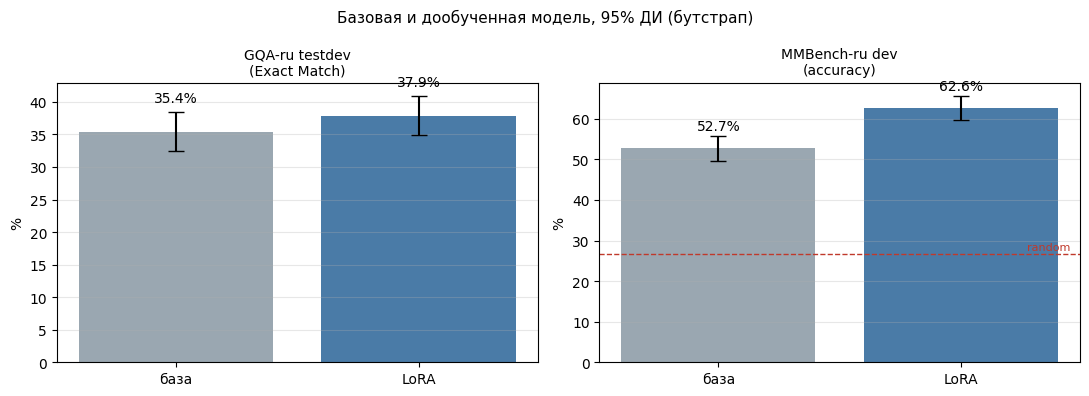

In [24]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

panels = [
    ("GQA-ru testdev\n(Exact Match)", gqa_base_mask, gqa_tuned_mask, None),
    ("MMBench-ru dev\n(accuracy)", mmb_base_mask, mmb_tuned_mask, mmb_random),
]

for ax, (title, bm, tm, rnd) in zip(axes, panels):
    vals, los, his = [], [], []
    for m in (bm, tm):
        a, lo, hi = bootstrap_ci(m)
        vals.append(a * 100)
        los.append((a - lo) * 100)
        his.append((hi - a) * 100)

    ax.bar(["база", "LoRA"], vals, yerr=[los, his], capsize=6,
           color=["#9aa7b1", "#4a7ba7"])
    if rnd is not None:
        ax.axhline(rnd * 100, linestyle="--", linewidth=1, color="#c0392b")
        ax.text(1.45, rnd * 100 + 1, "random", color="#c0392b", fontsize=8, ha="right")
    for i, v in enumerate(vals):
        ax.text(i, v + max(his) + 1.5, f"{v:.1f}%", ha="center", fontsize=10)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("%")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Базовая и дообученная модель, 95% ДИ (бутстрап)", fontsize=11)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/metrics_comparison.png", dpi=150)
plt.show()

## 14. Разбор ошибок


In [20]:
gqa_df = pd.DataFrame(gqa_tuned_rec)

print("Топ-10 эталонных ответов, которые модель чаще всего не угадывает:\n")
miss = gqa_df[~gqa_df["correct"]]["gt"].value_counts().head(10)
print(miss.to_string())

print("\n\nДоля пустых ответов:", f'{(gqa_df["pred"] == "").mean():.3f}')

print("\n\nПримеры расхождений база / LoRA:\n")
merged = pd.DataFrame(gqa_base_rec)[["index", "pred", "correct"]].rename(
    columns={"pred": "pred_base", "correct": "correct_base"}
).merge(
    gqa_df[["index", "question", "gt", "pred", "correct"]].rename(
        columns={"pred": "pred_tuned", "correct": "correct_tuned"}
    ),
    on="index",
)
diff_rows = merged[merged["correct_base"] != merged["correct_tuned"]].head(10)
print(diff_rows[["question", "gt", "pred_base", "pred_tuned"]].to_string(index=False))

mmb_df = pd.DataFrame(mmb_tuned_rec)
print("\n\nMMBench: accuracy по числу вариантов ответа\n")
print(mmb_df.groupby("n_options")["correct"].agg(["mean", "count"]).to_string())

Топ-10 эталонных ответов, которые модель чаще всего не угадывает:

gt
нет        85
да         60
стул        9
справа      9
слева       9
девочка     6
мужчина     6
стол        6
белый       6
плита       6


Доля пустых ответов: 0.000


Примеры расхождений база / LoRA:

                                                question        gt pred_base pred_tuned
Из какого материала сделан знак стоп на верхушке столба?    металл        из     металл
                Какие предметы мебели сделаны из дерева?     шкафы     шкафы      полки
                                  Что висит над цветами?   картина      вело    картина
                                Кого преследует мужчина?   женщину   женщина    женщину
                   Салфетка сделана из ткани или бумаги?    бумага    бумага      ткань
                                    Какого размера окно? маленькое маленькое    большое
    Девушка слева или справа от серебристого автомобиля?    справа     слева     справа
              Монитор

## 15. Сохранение результатов на Google Drive

In [21]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
    os.makedirs(DRIVE_DIR, exist_ok=True)
    for fname in os.listdir(RESULTS_DIR):
        shutil.copy(os.path.join(RESULTS_DIR, fname), DRIVE_DIR)
    print("Результаты скопированы в", DRIVE_DIR)
except Exception as e:
    print("Drive недоступен:", e)

archive = shutil.make_archive("/content/eval_results", "zip", RESULTS_DIR)
print("Архив:", archive, f"({os.path.getsize(archive) / 1e6:.1f} МБ)")

print("\nСодержимое:")
for fname in sorted(os.listdir(RESULTS_DIR)):
    print("  -", fname)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Результаты скопированы в /content/drive/MyDrive/llava-gemma-gqa-ru
Архив: /content/eval_results.zip (0.1 МБ)

Содержимое:
  - metrics_comparison.png
  - predictions_gqa.csv
  - predictions_mmbench.csv
  - results_summary.csv


## 16. Перенос в README

Готовые числа для таблицы результатов и раздела «Выводы».

In [22]:
print("Строки для таблицы в README.md:\n")
print("| Модель | GQA-ru testdev, Exact Match | MMBench-ru dev, accuracy |")
print("|---|---|---|")
print(f"| Случайное угадывание | — | {mmb_random * 100:.1f}% |")

g = summary.iloc[0]
m = summary.iloc[1]
print(f"| `deepvk/llava-gemma-2b-lora` (база, 4-bit) | "
      f"{g['base'] * 100:.1f} ± {(g['base_hi'] - g['base_lo']) / 2 * 100:.1f}% | "
      f"{m['base'] * 100:.1f} ± {(m['base_hi'] - m['base_lo']) / 2 * 100:.1f}% |")
print(f"| + наш LoRA-адаптер | "
      f"{g['tuned'] * 100:.1f} ± {(g['tuned_hi'] - g['tuned_lo']) / 2 * 100:.1f}% | "
      f"{m['tuned'] * 100:.1f} ± {(m['tuned_hi'] - m['tuned_lo']) / 2 * 100:.1f}% |")
print(f"| Разница | {g['diff'] * 100:+.1f} п.п., p = {g['p_value']:.3f} | "
      f"{m['diff'] * 100:+.1f} п.п., p = {m['p_value']:.3f} |")
print("| Опубликовано авторами (fp32, `lmms-eval`) | 46.37 | 40.19 |")

print("\n\nВариант вывода, подходящий по результатам:\n")
any_sig = bool(summary["significant_at_0.05"].any())
if any_sig:
    print("ВАРИАНТ Б — есть статистически значимый прирост хотя бы на одном бенчмарке.")
    for _, r in summary[summary["significant_at_0.05"]].iterrows():
        print(f"   {r['benchmark']}: {r['diff'] * 100:+.1f} п.п., p = {r['p_value']:.4f}")
else:
    print("ВАРИАНТ А — разница на обоих бенчмарках в пределах шума.")
    print("   Ожидаемый результат: авторы базовой модели уже использовали train-сплит")
    print("   GQA-ru с тем же пост-промптом на этапе instruction tuning.")

print(f"\nEVAL_N_GQA = {EVAL_N_GQA}, EVAL_N_MMBENCH = {EVAL_N_MMBENCH}, "
      f"бутстрап {N_BOOTSTRAP} итераций, seed = {SEED}")

Строки для таблицы в README.md:

| Модель | GQA-ru testdev, Exact Match | MMBench-ru dev, accuracy |
|---|---|---|
| Случайное угадывание | — | 26.7% |
| `deepvk/llava-gemma-2b-lora` (база, 4-bit) | 35.4 ± 3.0% | 52.7 ± 3.1% |
| + наш LoRA-адаптер | 37.9 ± 3.0% | 62.6 ± 3.0% |
| Разница | +2.5 п.п., p = 0.058 | +9.9 п.п., p = 0.000 |
| Опубликовано авторами (fp32, `lmms-eval`) | 46.37 | 40.19 |


Вариант вывода, подходящий по результатам:

ВАРИАНТ Б — есть статистически значимый прирост хотя бы на одном бенчмарке.
   MMBench-ru dev (accuracy): +9.9 п.п., p = 0.0000

EVAL_N_GQA = 1000, EVAL_N_MMBENCH = 1000, бутстрап 10000 итераций, seed = 42


---

# 17. Эксперимент: влияние токена `<bos>`

## Зачем

Chat template этого чекпоинта не вставляет `<bos>` (видно в разделе 4), и основной прогон
выполнен с `ADD_SPECIAL_TOKENS = False`, то есть **без BOS вообще**. Адаптер обучался
именно в этом режиме, а базовая модель — нет: на контрольной картинке она вырождается
в повтор инструкции вместо ответа.

Значит, измеренный прирост LoRA может складываться из двух разных вещей:

- **реального эффекта дообучения** — модель научилась краткому формату ответа;
- **артефакта формата промпта** — база измеряется вне своего штатного режима и проигрывает
  не из-за качества, а из-за отсутствия BOS.

Пока эти два вклада не разделены, утверждение «дообучение дало +9.9 п.п.» уязвимо.

## Что делает этот раздел

Прогоняет все четыре комбинации `модель × наличие BOS` на обоих бенчмарках и строит
таблицу 2×2 с доверительными интервалами и тестами Макнемара по двум осям:

|  | без BOS | с BOS |
|---|---|---|
| **База** | уже посчитано | будет посчитано |
| **LoRA** | уже посчитано | будет посчитано |

Результаты основного прогона переиспользуются автоматически, поэтому в живой сессии
досчитываются только два недостающих столбца. Каждая конфигурация кэшируется на диск
сразу после расчёта — при обрыве сессии повторно считаются только незавершённые.

In [ ]:
# 17.1 Конфигурация 

SWEEP_N_GQA = EVAL_N_GQA          
SWEEP_N_MMBENCH = EVAL_N_MMBENCH

SWEEP_CACHE = os.path.join(RESULTS_DIR, "bos_sweep")
os.makedirs(SWEEP_CACHE, exist_ok=True)

_MAIN_BOS = ADD_SPECIAL_TOKENS    # режим, в котором прошёл основной прогон

BENCHMARKS = ["GQA-ru", "MMBench-ru"]
BOS_MODES = [False, True]
MODELS = ["base", "lora"]


def _sweep_path(benchmark, bos, which):
    tag = "bos" if bos else "nobos"
    slug = benchmark.replace("-", "_")
    return os.path.join(SWEEP_CACHE, f"{slug}__{tag}__{which}.npy")


def _indices(benchmark):
    # random.Random(SEED).sample детерминирован при одних и тех же range и k, поэтому индексы совпадут с основным прогоном даже после перезапуска сессии.
    if benchmark == "GQA-ru":
        if "gqa_idx" in globals() and len(gqa_idx) == SWEEP_N_GQA:
            return gqa_idx
        return random.Random(SEED).sample(range(len(gqa_instructions)),
                                          min(SWEEP_N_GQA, len(gqa_instructions)))
    if "mmb_idx" in globals() and len(mmb_idx) == SWEEP_N_MMBENCH:
        return mmb_idx
    return random.Random(SEED).sample(range(len(mmbench_ds)),
                                      min(SWEEP_N_MMBENCH, len(mmbench_ds)))


# Переиспользуем то, что уже посчитано в разделах 11-12 
_from_main = {
    ("GQA-ru", _MAIN_BOS, "base"): globals().get("gqa_base_mask"),
    ("GQA-ru", _MAIN_BOS, "lora"): globals().get("gqa_tuned_mask"),
    ("MMBench-ru", _MAIN_BOS, "base"): globals().get("mmb_base_mask"),
    ("MMBench-ru", _MAIN_BOS, "lora"): globals().get("mmb_tuned_mask"),
}

reused = 0
for key, mask in _from_main.items():
    if mask is None:
        continue
    expected = SWEEP_N_GQA if key[0] == "GQA-ru" else SWEEP_N_MMBENCH
    if len(mask) != expected:
        continue
    path = _sweep_path(*key)
    if not os.path.exists(path):
        np.save(path, np.asarray(mask, dtype=bool))
        reused += 1

todo = [(b, s, m) for b in BENCHMARKS for s in BOS_MODES for m in MODELS
        if not os.path.exists(_sweep_path(b, s, m))]

gen_needed = sum(SWEEP_N_GQA if t[0] == "GQA-ru" else SWEEP_N_MMBENCH for t in todo)
per_example = probe_time / 20 if "probe_time" in globals() else 0.56

print(f"Переиспользовано из основного прогона: {reused} конфигураций")
print(f"Найдено в кэше на диске: {8 - len(todo) - reused} конфигураций")
print(f"Осталось посчитать: {len(todo)} конфигураций, {gen_needed} генераций")
print(f"Ожидаемое время: ~{gen_needed * per_example / 60:.0f} мин\n")
for t in todo:
    print("  -", t[0], "| BOS:", t[1], "|", t[2])

Переиспользовано из основного прогона: 0 конфигураций
Найдено в кэше на диске: 4 конфигураций
Осталось посчитать: 4 конфигураций, 4000 генераций
Ожидаемое время: ~37 мин

  - GQA-ru | BOS: True | base
  - GQA-ru | BOS: True | lora
  - MMBench-ru | BOS: True | base
  - MMBench-ru | BOS: True | lora


## 17.2 Прогон недостающих конфигураций

Ячейка меняет глобальный `ADD_SPECIAL_TOKENS` перед каждым замером и возвращает исходное
значение в конце.

In [ ]:
def run_config(benchmark, bos, which):
    global ADD_SPECIAL_TOKENS
    prev = ADD_SPECIAL_TOKENS
    ADD_SPECIAL_TOKENS = bos
    try:
        idx = _indices(benchmark)
        fn = evaluate_gqa if benchmark == "GQA-ru" else evaluate_mmbench
        tag = f"{'bos' if bos else 'nobos'}/{which}"
        if which == "base":
            with model.disable_adapter():
                return fn(model, idx, desc=tag)
        return fn(model, idx, desc=tag)
    finally:
        ADD_SPECIAL_TOKENS = prev


sweep_records = []
t_start = time.time()

for benchmark, bos, which in todo:
    print(f"\n>>> {benchmark} | BOS={bos} | {which}")
    mask, rec = run_config(benchmark, bos, which)
    np.save(_sweep_path(benchmark, bos, which), mask)
    for r in rec:
        r["bos"] = bos
        r["model"] = which
    sweep_records.extend(rec)
    print(f"    accuracy: {mask.mean():.4f}  (сохранено)")

if sweep_records:
    pd.DataFrame(sweep_records).to_csv(f"{RESULTS_DIR}/predictions_bos_sweep.csv", index=False)

print(f"\nГотово за {(time.time() - t_start) / 60:.1f} мин.")

# Собираем все четыре конфигурации из кэша
sweep_masks = {}
for benchmark in BENCHMARKS:
    for bos in BOS_MODES:
        for which in MODELS:
            sweep_masks[(benchmark, bos, which)] = np.load(_sweep_path(benchmark, bos, which))

print("Загружено конфигураций:", len(sweep_masks))
print("Режим ADD_SPECIAL_TOKENS восстановлен:", ADD_SPECIAL_TOKENS)


>>> GQA-ru | BOS=True | base


GQA/bos/base:   0%|          | 0/125 [00:00<?, ?it/s]

    accuracy: 0.3960  (сохранено)

>>> GQA-ru | BOS=True | lora


GQA/bos/lora:   0%|          | 0/125 [00:00<?, ?it/s]

    accuracy: 0.3920  (сохранено)

>>> MMBench-ru | BOS=True | base


MMBench/bos/base:   0%|          | 0/125 [00:00<?, ?it/s]

    accuracy: 0.6320  (сохранено)

>>> MMBench-ru | BOS=True | lora


MMBench/bos/lora:   0%|          | 0/125 [00:00<?, ?it/s]

    accuracy: 0.6430  (сохранено)

Готово за 20.4 мин.
Загружено конфигураций: 8
Режим ADD_SPECIAL_TOKENS восстановлен: False


## 17.3 Таблица 2×2 и два разреза статистики

Тест Макнемара применяется дважды:

- **эффект дообучения** — LoRA против базы внутри каждого режима BOS;
- **эффект формата** — с BOS против без BOS внутри каждой модели.

Второй разрез и отвечает на исходный вопрос: если база сильно выигрывает от BOS, а LoRA
почти нет, значит основной прогон измерял базу вне её штатного режима.



In [28]:
def _fmt(mask):
    a, lo, hi = bootstrap_ci(mask)
    return f"{a * 100:5.2f}% [{lo * 100:5.2f}; {hi * 100:5.2f}]"


print("=" * 78)
print("ТАБЛИЦА 2x2".center(78))
print("=" * 78)
for benchmark in BENCHMARKS:
    n = len(sweep_masks[(benchmark, False, "base")])
    print(f"\n{benchmark}  (n = {n})")
    print(f"  {'':6s} {'без BOS':>24s}   {'с BOS':>24s}")
    for which in MODELS:
        label = "База" if which == "base" else "LoRA"
        print(f"  {label:6s} {_fmt(sweep_masks[(benchmark, False, which)]):>24s}   "
              f"{_fmt(sweep_masks[(benchmark, True, which)]):>24s}")

lora_rows, bos_rows = [], []

print("\n" + "=" * 78)
print("ЭФФЕКТ ДООБУЧЕНИЯ (LoRA - база), внутри каждого режима BOS")
print("=" * 78)
for benchmark in BENCHMARKS:
    for bos in BOS_MODES:
        b = sweep_masks[(benchmark, bos, "base")]
        t = sweep_masks[(benchmark, bos, "lora")]
        d, d_lo, d_hi = bootstrap_diff_ci(b, t)
        n_b, n_c, p = mcnemar(b, t)
        lora_rows.append({"benchmark": benchmark, "bos": bos, "base": b.mean(),
                          "lora": t.mean(), "diff": d, "lo": d_lo, "hi": d_hi,
                          "base_only": n_b, "lora_only": n_c, "p": p})
        star = "значимо" if p < 0.05 else "не значимо"
        print(f"  {benchmark:12s} BOS={str(bos):5s}  {d * 100:+6.2f} п.п. "
              f"[{d_lo * 100:+6.2f}; {d_hi * 100:+6.2f}]  p={p:.4f}  ({star})")

print("\n" + "=" * 78)
print("ЭФФЕКТ ФОРМАТА (с BOS - без BOS), внутри каждой модели")
print("=" * 78)
for benchmark in BENCHMARKS:
    for which in MODELS:
        nb = sweep_masks[(benchmark, False, which)]
        wb = sweep_masks[(benchmark, True, which)]
        d, d_lo, d_hi = bootstrap_diff_ci(nb, wb)
        n_b, n_c, p = mcnemar(nb, wb)
        bos_rows.append({"benchmark": benchmark, "model": which, "nobos": nb.mean(),
                         "bos": wb.mean(), "diff": d, "lo": d_lo, "hi": d_hi, "p": p})
        star = "значимо" if p < 0.05 else "не значимо"
        label = "База" if which == "base" else "LoRA"
        print(f"  {benchmark:12s} {label:5s}      {d * 100:+6.2f} п.п. "
              f"[{d_lo * 100:+6.2f}; {d_hi * 100:+6.2f}]  p={p:.4f}  ({star})")

lora_df = pd.DataFrame(lora_rows)
bos_df = pd.DataFrame(bos_rows)
lora_df.to_csv(f"{RESULTS_DIR}/bos_sweep_lora_effect.csv", index=False)
bos_df.to_csv(f"{RESULTS_DIR}/bos_sweep_bos_effect.csv", index=False)
print("\nСохранено: bos_sweep_lora_effect.csv, bos_sweep_bos_effect.csv")

                                 ТАБЛИЦА 2x2                                  

GQA-ru  (n = 1000)
                          без BOS                      с BOS
  База      35.40% [32.40; 38.50]      39.60% [36.60; 42.60]
  LoRA      37.90% [34.90; 40.90]      39.20% [36.20; 42.30]

MMBench-ru  (n = 1000)
                          без BOS                      с BOS
  База      52.70% [49.60; 55.80]      63.20% [60.20; 66.20]
  LoRA      62.60% [59.60; 65.60]      64.30% [61.40; 67.30]

ЭФФЕКТ ДООБУЧЕНИЯ (LoRA - база), внутри каждого режима BOS
  GQA-ru       BOS=False   +2.50 п.п. [ -0.10;  +5.00]  p=0.0582  (не значимо)
  GQA-ru       BOS=True    -0.40 п.п. [ -2.00;  +1.20]  p=0.7122  (не значимо)
  MMBench-ru   BOS=False   +9.90 п.п. [ +7.00; +12.80]  p=0.0000  (значимо)
  MMBench-ru   BOS=True    +1.10 п.п. [ -0.80;  +3.00]  p=0.3049  (не значимо)

ЭФФЕКТ ФОРМАТА (с BOS - без BOS), внутри каждой модели
  GQA-ru       База        +4.20 п.п. [ +1.10;  +7.30]  p=0.0083  (значимо)
  GQA-

## 17.4 Интерпретация

Ячейка ниже сравнивает эффект дообучения в двух режимах промпта.

In [29]:
print("Как изменился эффект дообучения при добавлении BOS:\n")

for benchmark in BENCHMARKS:
    row_no = lora_df[(lora_df.benchmark == benchmark) & (~lora_df.bos)].iloc[0]
    row_yes = lora_df[(lora_df.benchmark == benchmark) & (lora_df.bos)].iloc[0]

    d_no, d_yes = row_no["diff"] * 100, row_yes["diff"] * 100
    keep = d_yes / d_no if abs(d_no) > 1e-9 else float("nan")

    print(f"{benchmark}")
    print(f"  без BOS: {d_no:+.2f} п.п. (p={row_no['p']:.4f})")
    print(f"  с BOS  : {d_yes:+.2f} п.п. (p={row_yes['p']:.4f})")

    if not np.isnan(keep) and keep < 0 and row_yes["p"] < 0.05:
        verdict = ("знак эффекта развернулся: с BOS базовая модель обходит дообученную. "
                   "Это значит, что в основном прогоне преимущество LoRA целиком "
                   "объяснялось форматом промпта. В отчёте нужно приводить обе колонки.")
    elif row_yes["p"] >= 0.05 and row_no["p"] < 0.05:
        verdict = ("прирост держался на формате промпта: с BOS он перестаёт быть значимым. "
                   "В отчёте нельзя утверждать, что дообучение улучшило метрику.")
    elif not np.isnan(keep) and keep >= 0.7:
        verdict = ("эффект устойчив к формату промпта — сохраняется почти целиком. "
                   "Можно уверенно приписывать его дообучению.")
    elif not np.isnan(keep) and keep >= 0.3:
        verdict = (f"эффект сохраняется частично (~{keep * 100:.0f}% исходной величины). "
                   "В отчёте стоит указать обе цифры и признать смешанный вклад.")
    else:
        verdict = ("эффект почти исчезает при добавлении BOS — основной вклад давал "
                   "формат промпта, а не дообучение.")
    print(f"  ВЫВОД: {verdict}\n")

print("-" * 78)
print("Насколько каждая модель зависит от BOS:\n")
for benchmark in BENCHMARKS:
    b = bos_df[(bos_df.benchmark == benchmark) & (bos_df.model == "base")].iloc[0]
    l = bos_df[(bos_df.benchmark == benchmark) & (bos_df.model == "lora")].iloc[0]
    print(f"{benchmark}: база {b['diff'] * 100:+.2f} п.п. (p={b['p']:.4f}), "
          f"LoRA {l['diff'] * 100:+.2f} п.п. (p={l['p']:.4f})")
    if b["diff"] > l["diff"] + 0.02:
        print("  База выигрывает от BOS заметно сильнее — подтверждает, что в основном")
        print("  прогоне она измерялась вне своего штатного режима.\n")
    else:
        print("  Обе модели реагируют на BOS схоже — основной прогон был к базе честен.\n")

Как изменился эффект дообучения при добавлении BOS:

GQA-ru
  без BOS: +2.50 п.п. (p=0.0582)
  с BOS  : -0.40 п.п. (p=0.7122)
  ВЫВОД: эффект почти исчезает при добавлении BOS — основной вклад давал формат промпта, а не дообучение.

MMBench-ru
  без BOS: +9.90 п.п. (p=0.0000)
  с BOS  : +1.10 п.п. (p=0.3049)
  ВЫВОД: прирост держался на формате промпта: с BOS он перестаёт быть значимым. В отчёте нельзя утверждать, что дообучение улучшило метрику.

------------------------------------------------------------------------------
Насколько каждая модель зависит от BOS:

GQA-ru: база +4.20 п.п. (p=0.0083), LoRA +1.30 п.п. (p=0.2753)
  База выигрывает от BOS заметно сильнее — подтверждает, что в основном
  прогоне она измерялась вне своего штатного режима.

MMBench-ru: база +10.50 п.п. (p=0.0000), LoRA +1.70 п.п. (p=0.0604)
  База выигрывает от BOS заметно сильнее — подтверждает, что в основном
  прогоне она измерялась вне своего штатного режима.



## 17.5 График

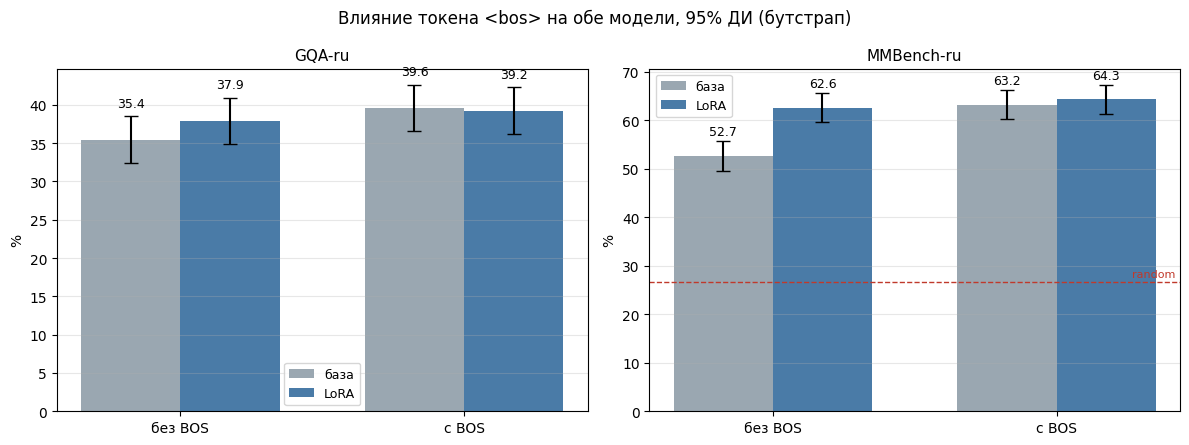

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
width = 0.35
x = np.arange(2)

for ax, benchmark in zip(axes, BENCHMARKS):
    for i, which in enumerate(MODELS):
        vals, los, his = [], [], []
        for bos in BOS_MODES:
            a, lo, hi = bootstrap_ci(sweep_masks[(benchmark, bos, which)])
            vals.append(a * 100)
            los.append((a - lo) * 100)
            his.append((hi - a) * 100)
        label = "база" if which == "base" else "LoRA"
        bars = ax.bar(x + (i - 0.5) * width, vals, width, yerr=[los, his], capsize=5,
                      label=label, color=["#9aa7b1", "#4a7ba7"][i])
        for xi, v in zip(x + (i - 0.5) * width, vals):
            ax.text(xi, v + max(his) + 1.2, f"{v:.1f}", ha="center", fontsize=9)

    if benchmark == "MMBench-ru" and "mmb_random" in globals():
        ax.axhline(mmb_random * 100, linestyle="--", linewidth=1, color="#c0392b")
        ax.text(1.42, mmb_random * 100 + 1, "random", color="#c0392b", fontsize=8, ha="right")

    ax.set_xticks(x)
    ax.set_xticklabels(["без BOS", "с BOS"])
    ax.set_title(benchmark, fontsize=11)
    ax.set_ylabel("%")
    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=9)

plt.suptitle("Влияние токена <bos> на обе модели, 95% ДИ (бутстрап)", fontsize=12)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/bos_sweep_comparison.png", dpi=150)
plt.show()

## 17.6 Готовая таблица для README

In [31]:
print("| Модель | GQA-ru, без BOS | GQA-ru, с BOS | MMBench-ru, без BOS | MMBench-ru, с BOS |")
print("|---|---|---|---|---|")


def cell(benchmark, bos, which):
    a, lo, hi = bootstrap_ci(sweep_masks[(benchmark, bos, which)])
    return f"{a * 100:.1f} ± {(hi - lo) / 2 * 100:.1f}%"


for which in MODELS:
    label = "`deepvk/llava-gemma-2b-lora` (база)" if which == "base" else "**+ наш LoRA-адаптер**"
    print(f"| {label} | {cell('GQA-ru', False, which)} | {cell('GQA-ru', True, which)} | "
          f"{cell('MMBench-ru', False, which)} | {cell('MMBench-ru', True, which)} |")

diffs = []
for benchmark in BENCHMARKS:
    for bos in BOS_MODES:
        r = lora_df[(lora_df.benchmark == benchmark) & (lora_df.bos == bos)].iloc[0]
        diffs.append(f"{r['diff'] * 100:+.1f} п.п., p = {r['p']:.3f}")
print(f"| Разница | {diffs[0]} | {diffs[1]} | {diffs[2]} | {diffs[3]} |")

print(f"\nn = {SWEEP_N_GQA} (GQA-ru) и {SWEEP_N_MMBENCH} (MMBench-ru) на конфигурацию, "
      f"интервалы — 95% бутстрап ({N_BOOTSTRAP} итераций), p — точный тест Макнемара.")
print("Опубликовано авторами (fp32, lmms-eval): GQA-ru 46.37 | MMBench-ru 40.19")

if "mmb_random" in globals():
    print(f"Random baseline MMBench-ru: {mmb_random * 100:.1f}%")

| Модель | GQA-ru, без BOS | GQA-ru, с BOS | MMBench-ru, без BOS | MMBench-ru, с BOS |
|---|---|---|---|---|
| `deepvk/llava-gemma-2b-lora` (база) | 35.4 ± 3.0% | 39.6 ± 3.0% | 52.7 ± 3.1% | 63.2 ± 3.0% |
| **+ наш LoRA-адаптер** | 37.9 ± 3.0% | 39.2 ± 3.0% | 62.6 ± 3.0% | 64.3 ± 3.0% |
| Разница | +2.5 п.п., p = 0.058 | -0.4 п.п., p = 0.712 | +9.9 п.п., p = 0.000 | +1.1 п.п., p = 0.305 |

n = 1000 (GQA-ru) и 1000 (MMBench-ru) на конфигурацию, интервалы — 95% бутстрап (10000 итераций), p — точный тест Макнемара.
Опубликовано авторами (fp32, lmms-eval): GQA-ru 46.37 | MMBench-ru 40.19
Random baseline MMBench-ru: 26.7%


In [ ]:
# Копируем свежие результаты на Google Drive
try:
    from google.colab import drive
    drive.mount("/content/drive")
    os.makedirs(DRIVE_DIR, exist_ok=True)
    for fname in os.listdir(RESULTS_DIR):
        src = os.path.join(RESULTS_DIR, fname)
        if os.path.isfile(src):
            shutil.copy(src, DRIVE_DIR)
    print("Результаты обновлены в", DRIVE_DIR)
except Exception as e:
    print("Drive недоступен:", e)

archive = shutil.make_archive("/content/eval_results", "zip", RESULTS_DIR)
print("Архив:", archive, f"({os.path.getsize(archive) / 1e6:.1f} МБ)")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Результаты обновлены в /content/drive/MyDrive/llava-gemma-gqa-ru
Архив: /content/eval_results.zip (0.3 МБ)


## 18. Диагностика: стратегия выбора визуальных признаков (default vs full)


**Зачем.** Базовая модель даёт 39.6% на GQA-ru против опубликованных 46.37%. 
Одна из гипотез: чекпоинты `deepvk/llava-*` обучались со стратегией `"full"` (все 577 признаков CLIP, включая CLS-токен), хотя в конфиге стоит `"default"` (576 патчей, CLS отбрасывается). Если гипотеза верна, часть визуальной информации сейчас теряется.

**Важно —  проверяем только базовую модель.**
 Адаптер обучался со стратегией `"default"`. Прогонять его с `"full"` значило бы измерять LoRA вне режима её обучения — ровно та ошибка, которую раздел 17 только что выявил с токеном `<bos>`. Вопрос здесь стоит исключительно про воспроизведение опубликованного числа БАЗОВОЙ модели, и LoRA к нему отношения не имеет.

**Режим промпта** — с `BOS`: это штатный режим базовой модели (см. раздел 17).

In [ ]:
PROBE_N = 200

probe_idx_vfs = random.Random(SEED).sample(range(len(gqa_instructions)), PROBE_N)


def set_vision_strategy(strategy: str) -> None:
    """Переключает стратегию выбора визуальных признаков.

    Стратегию нужно выставить в ДВУХ местах:
      - model.config  — определяет, отбрасывается ли CLS-токен из признаков
                        внутри get_image_features();
      - processor     — определяет, сколько плейсхолдеров <image> вставить
                        в текст.

    ГЛАВНАЯ ЛОВУШКА. num_additional_image_tokens описывает выход vision tower
    (CLS-токен = +1) и должен быть равен 1 в ОБОИХ режимах. Ветка "default"
    внутри процессора сама вычитает эту единицу:

        num_image_tokens = (H // patch) * (W // patch) + num_additional
        if strategy == "default":
            num_image_tokens -= 1

    То есть default -> 24*24 + 1 - 1 = 576, full -> 24*24 + 1 = 577.
    Если для "full" оставить num_additional_image_tokens = 0, процессор
    насчитает 576 плейсхолдеров против 577 признаков модели и упадёт с
    ValueError о несовпадении числа токенов.
    """
    model.config.vision_feature_select_strategy = strategy
    processor.vision_feature_select_strategy = strategy
    processor.num_additional_image_tokens = 1


_prev_bos = ADD_SPECIAL_TOKENS
ADD_SPECIAL_TOKENS = True          # штатный режим базовой модели

vfs_masks = {}

try:
    for strategy in ["default", "full"]:
        set_vision_strategy(strategy)
        print(f"\n>>> стратегия: {strategy}")
        try:
            with model.disable_adapter():
                mask, rec = evaluate_gqa(model, probe_idx_vfs, desc=f"base/{strategy}")
            vfs_masks[strategy] = mask
            print(f"    GQA-ru Exact Match: {mask.mean():.4f}")
        except Exception as e:
            print(f"    ОШИБКА при стратегии {strategy}: {type(e).__name__}: {e}")
            print("    Если это ValueError про несовпадение числа токенов —")
            print("    проверьте num_additional_image_tokens (должен быть 1).")
finally:
    set_vision_strategy("default")   # возвращаем исходное состояние
    ADD_SPECIAL_TOKENS = _prev_bos


# Итог 
if len(vfs_masks) == 2:
    a, b = vfs_masks["default"], vfs_masks["full"]
    d, lo, hi = bootstrap_diff_ci(a, b)
    n_a, n_b, p = mcnemar(a, b)

    print("\n" + "=" * 70)
    print(f"База, GQA-ru, n = {PROBE_N}, промпт с BOS")
    print(f"  default : {a.mean() * 100:5.2f}%")
    print(f"  full    : {b.mean() * 100:5.2f}%")
    print(f"  разница : {d * 100:+5.2f} п.п.  [{lo * 100:+5.2f}; {hi * 100:+5.2f}]  p = {p:.4f}")
    print("=" * 70)

    if p < 0.05 and d > 0:
        print("\nСтратегия 'full' значимо лучше. Это измеренное объяснение части")
        print("разрыва с опубликованными 46.37%. Впишите величину в 'Ограничения'.")
        print("Переделывать основной свип НЕ обязательно: он самосогласован,")
        print("обе модели там измерены в одинаковых условиях.")
    elif p < 0.05 and d < 0:
        print("\nСтратегия 'full' значимо ХУЖЕ — конфиг чекпоинта корректен,")
        print("гипотеза не подтвердилась. Запишите как проверенную и отклонённую.")
    else:
        print("\nРазницы нет (или она в пределах шума на 200 примерах).")
        print("Гипотеза не подтвердилась: разрыв с 46.37% нужно объяснять")
        print("другими причинами — квантованием и деталями протокола lmms-eval.")
        print(f"На n = {PROBE_N} обнаружимы эффекты примерно от 7 п.п. и выше;")
        print("если хотите ловить меньшие — увеличьте PROBE_N до 1000.")
else:
    print("\nОдна из конфигураций не отработала — см. сообщение об ошибке выше.")


>>> стратегия: default


GQA/base/default:   0%|          | 0/25 [00:00<?, ?it/s]

    GQA-ru Exact Match: 0.3900

>>> стратегия: full


GQA/base/full:   0%|          | 0/25 [00:00<?, ?it/s]

    GQA-ru Exact Match: 0.3600

База, GQA-ru, n = 200, промпт с BOS
  default : 39.00%
  full    : 36.00%
  разница : -3.00 п.п.  [-7.50; +1.50]  p = 0.2863

Разницы нет (или она в пределах шума на 200 примерах).
Гипотеза не подтвердилась: разрыв с 46.37% нужно объяснять
другими причинами — квантованием и деталями протокола lmms-eval.
На n = 200 обнаружимы эффекты примерно от 7 п.п. и выше;
если хотите ловить меньшие — увеличьте PROBE_N до 1000.


## 19. Качественная иллюстрация: модель × режим промпта

**Зачем.** Таблицы показывают, что происходит (база теряет 4-10 п.п. без BOS, LoRA не теряет). Эта картинка показывает, Как это выглядит: базовая модель без BOS вырождается в пересказ инструкции, а с BOS отвечает нормально. Именно эта строчка в sanity check и заставила заподозрить конфаунд.

**Честность выборки.** Два примера из GQA берутся автоматически: один, где выигрывает LoRA, и один, где выигрывает база. Совокупный эффект дообучения статистически не значим, и подборка примеров не должна намекать на обратное.

Примеры выбраны из /content/drive/MyDrive/llava-gemma-gqa-ru/predictions_gqa.csv
  расхождений: LoRA права в 93, база права в 68


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


... Открытый вопрос
Режим ADD_SPECIAL_TOKENS восстановлен: False


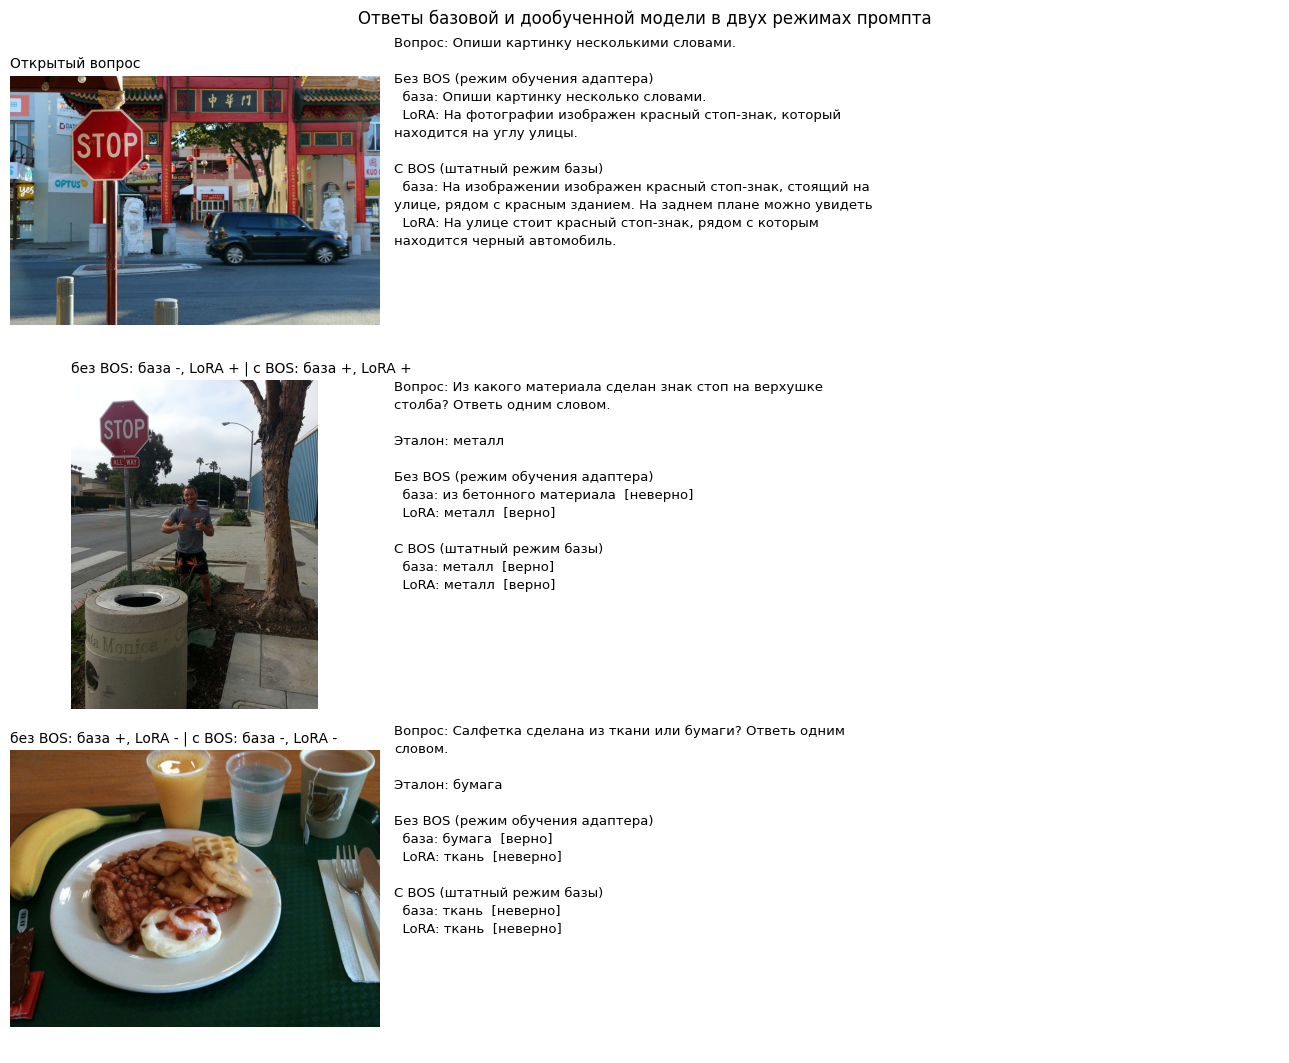


Сохранено: /content/results/qualitative_bos.png и qualitative_bos.json


In [ ]:
import textwrap
import json
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

MAX_NEW_OPEN = 30   # для открытого вопроса
MAX_NEW_SHORT = 10  # для вопросов GQA


def four_answers(image, question, max_new_tokens):
    """Возвращает 4 ответа: {(модель, есть_ли_BOS): текст}."""
    global ADD_SPECIAL_TOKENS
    prev = ADD_SPECIAL_TOKENS
    out = {}
    try:
        for bos in (False, True):
            ADD_SPECIAL_TOKENS = bos
            with model.disable_adapter():
                out[("base", bos)] = generate_answers(model, [image], [question], max_new_tokens)[0]
            out[("lora", bos)] = generate_answers(model, [image], [question], max_new_tokens)[0]
    finally:
        ADD_SPECIAL_TOKENS = prev
    return out


# Собираем примеры 
examples = []

# 1. Открытый вопрос — здесь вырождение видно ярче всего
stop_sign = Image.open(
    requests.get("https://www.ilankelman.org/stopsigns/australia.jpg", stream=True).raw
).convert("RGB")
examples.append({
    "image": stop_sign,
    "question": "Опиши картинку несколькими словами.",
    "gt": None,
    "caption": "Открытый вопрос",
    "max_new": MAX_NEW_OPEN,
})

# 2-3. Два примера из GQA: один в пользу LoRA, один в пользу базы.
if "gqa_base_mask" in globals() and "gqa_idx" in globals():
    lora_wins = [gqa_idx[i] for i, (b, t) in enumerate(zip(gqa_base_mask, gqa_tuned_mask))
                 if not b and t]
    base_wins = [gqa_idx[i] for i, (b, t) in enumerate(zip(gqa_base_mask, gqa_tuned_mask))
                 if b and not t]
    print("Примеры выбраны из масок в памяти.")
else:
    csv_path = os.path.join(RESULTS_DIR, "predictions_gqa.csv")
    if not os.path.exists(csv_path):
        csv_path = os.path.join(DRIVE_DIR, "predictions_gqa.csv")
    _df = pd.read_csv(csv_path)
    _b = _df[_df.model == "base"].set_index("index")["correct"].astype(bool)
    _t = _df[_df.model == "tuned"].set_index("index")["correct"].astype(bool)
    common = _b.index.intersection(_t.index)
    lora_wins = [i for i in common if not _b[i] and _t[i]]
    base_wins = [i for i in common if _b[i] and not _t[i]]
    print(f"Примеры выбраны из {csv_path}")

print(f"  расхождений: LoRA права в {len(lora_wins)}, база права в {len(base_wins)}")

def _norm(text):
    parts = str(text).strip().lower().split()
    return parts[0].strip(STRIP_CHARS) if parts else ""



N_CANDIDATES = 4

for pool, why in ((lora_wins, "по маскам: LoRA права, база нет"),
                  (base_wins, "по маскам: база права, LoRA нет")):
    if not pool:
        continue
    chosen = None
    for cand in pool[:N_CANDIDATES]:
        item = gqa_instructions[int(cand)]
        img = gqa_images[gqa_id_to_idx[item["imageId"]]]["image"].convert("RGB")
        question = f'{str(item["question"]).strip()} {POST_PROMPT_GQA}'
        ans = four_answers(img, question, MAX_NEW_SHORT)
        differs = any(_norm(ans[("base", b)]) != _norm(ans[("lora", b)]) for b in (False, True))
        if differs or chosen is None:
            chosen = {
                "image": img,
                "question": question,
                "gt": str(item["answer"]).strip().lower(),
                "caption": why,
                "max_new": MAX_NEW_SHORT,
                "answers": ans,
            }
        if differs:
            break
    examples.append(chosen)

# Прогоняем то, что ещё не посчитано 
for ex in examples:
    if "answers" not in ex:
        print("...", ex["caption"])
        ex["answers"] = four_answers(ex["image"], ex["question"], ex["max_new"])

# Подпись строим по фактически показанным ответам, а не по маскам
for ex in examples:
    if not ex["gt"]:
        continue
    marks = []
    for bos in (False, True):
        b_ok = _norm(ex["answers"][("base", bos)]) == ex["gt"]
        l_ok = _norm(ex["answers"][("lora", bos)]) == ex["gt"]
        marks.append(f"{'с BOS' if bos else 'без BOS'}: база {'+' if b_ok else '-'}, "
                     f"LoRA {'+' if l_ok else '-'}")
    ex["caption"] = " | ".join(marks)

print("Режим ADD_SPECIAL_TOKENS восстановлен:", ADD_SPECIAL_TOKENS)

# Рисуем 
n = len(examples)
fig, axes = plt.subplots(n, 2, figsize=(13, 3.6 * n),
                         gridspec_kw={"width_ratios": [1, 2.4]})
if n == 1:
    axes = np.array([axes])

for row, ex in enumerate(examples):
    ax_img, ax_txt = axes[row, 0], axes[row, 1]

    ax_img.imshow(ex["image"])
    ax_img.axis("off")
    ax_img.set_title(ex["caption"], fontsize=10, loc="left")

    lines = ["\n".join(textwrap.wrap("Вопрос: " + ex["question"], 62)), ""]
    if ex["gt"]:
        lines.append(f"Эталон: {ex['gt']}")
        lines.append("")

    for bos in (False, True):
        lines.append(f"{'С BOS' if bos else 'Без BOS'} (штатный режим базы)"
                     if bos else f"{'Без BOS'} (режим обучения адаптера)")
        for which, label in (("base", "  база"), ("lora", "  LoRA")):
            txt = ex["answers"][(which, bos)].replace("\n", " ")
            mark = ""
            if ex["gt"]:
                mark = "  [верно]" if _norm(txt) == ex["gt"] else "  [неверно]"
            wrapped = textwrap.wrap(f"{label}: {txt}{mark}", 62) or [f"{label}: <пусто>"]
            lines.extend(wrapped)
        lines.append("")

    ax_txt.text(0, 1, "\n".join(lines), fontsize=9.5, va="top", ha="left",
                family="DejaVu Sans", linespacing=1.5)
    ax_txt.axis("off")

plt.suptitle("Ответы базовой и дообученной модели в двух режимах промпта", fontsize=12)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/qualitative_bos.png", dpi=150, bbox_inches="tight")
plt.show()

# Сохраняем текст, чтобы цитировать в отчёте 
dump = [{
    "caption": ex["caption"],
    "question": ex["question"],
    "gt": ex["gt"],
    "answers": {f"{w}_{'bos' if b else 'nobos'}": t for (w, b), t in ex["answers"].items()},
} for ex in examples]

with open(f"{RESULTS_DIR}/qualitative_bos.json", "w", encoding="utf-8") as f:
    json.dump(dump, f, ensure_ascii=False, indent=2)

print(f"\nСохранено: {RESULTS_DIR}/qualitative_bos.png и qualitative_bos.json")